# Cross-modal validation of DICOR Extreme-KDTR phenotype

## Aim

To evaluate whether the DICOR-derived Extreme-KDTR phenotype is associated with Speckle-Tracking Strain variability and LV geometry.

## Rationale

Notebook 07 identified an Extreme-KDTR tail phenotype that appeared only in patients with Distant + Transverse chord architecture. However, this finding is exploratory.

The next step is to test whether this phenotype is visible across other mechanical domains:

1. Speckle-Tracking Strain variability:
   - `echo_lv_strain_plus_cv_pct`
   - `echo_lv_strain_rate_cv_pct`

2. LV geometry:
   - sphericity index
   - LV diameter
   - LV volumes
   - ejection fraction

3. Minimal predictive modeling:
   - Extreme-KDTR as binary outcome
   - Distant + Transverse architecture as main predictor
   - limited adjustment for geometry if sample size allows

Because the Extreme-KDTR group is small, all models are treated as exploratory.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd

import scipy.stats as stats
from scipy.stats import fisher_exact

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path(r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords")

DATA_PATH = PROJECT_ROOT / "data" / "interim" / "07_dicor_extreme_kdtr_chord_architecture_dataset.xlsx"

OUTPUT_DIR = PROJECT_ROOT / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (68, 224)


,subject_full_name,age,height_cm,weight_cm,BSA,sex,IMT,echo_ascending_aorta_diameter_mm_div_bsa,echo_ascending_aorta_diameter_mm,echo_aortic_sinus_diameter_mm_div_bsa,echo_aortic_sinus_diameter_mm,echo_aortic_valve_annulus_diameter_mm,echo_aortic_cusp_separation_mm,Е/А,echo_lv_end_diastolic_volume_index_ml_m2,echo_lv_end_diastolic_volume_teichholz_ml,echo_lv_end_systolic_volume_index_ml_m2,echo_lv_end_systolic_volume_teichholz_ml,echo_lv_ejection_fraction_teichholz_pct,echo_lv_stroke_volume_teichholz_ml,echo_lv_end_diastolic_volume_index_simpson_ml_m2,echo_lv_end_diastolic_volume_simpson_ml,echo_lv_end_systolic_volume_index_simpson_ml_m2,echo_lv_end_systolic_volume_simpson_ml,echo_lv_ejection_fraction_simpson_pct,echo_lv_stroke_volume_simpson_ml,echo_lv_end_diastolic_diameter_mm,echo_lv_end_systolic_diameter_mm,echo_lv_myocardial_mass_index_g_m2,echo_lv_relative_wall_thickness_ratio,echo_interventricular_septum_thickness_mm,echo_lv_posterior_wall_thickness_mm,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio,dicor_mk_kdtr_01_mm,dicor_mk_ous_01_pct,dicor_mk_kdtr_02_mm,dicor_mk_ous_02_pct,dicor_mk_kdtr_03_mm,dicor_mk_ous_03_pct,dicor_mk_kdtr_04_mm,dicor_mk_ous_04_pct,dicor_sm_kdtr_01_mm,dicor_sm_ous_01_pct,dicor_sm_kdtr_02_mm,dicor_sm_ous_02_pct,dicor_sm_kdtr_03_mm,dicor_sm_ous_03_pct,dicor_sm_kdtr_04_mm,dicor_sm_ous_04_pct,dicor_v_kdtr_01_mm,dicor_v_ous_01_pct,dicor_v_kdtr_02_mm,dicor_v_ous_02_pct,dicor_v_kdtr_03_mm,dicor_v_ous_03_pct,dicor_v_kdtr_04_mm,dicor_v_ous_04_pct,dicor_sm_kdtr_cv_pct,dicor_cv_sfu_at_ksk_lv_pct,dicor_cv_sfu_at_ksk_regional_pct,dicor_cv_velocity_pct,dicor_cv_vmax_pct,dicor_delta_t_ms,dicor_real_ejection_fraction_pct,dicor_potential_ejection_fraction_pct,dicor_delta_ejection_fraction_pct,dicor_ssou_01_pct,dicor_ssou_02_pct,dicor_ssou_03_pct,dicor_ssou_04_pct,dicor_ssou_05_pct,dicor_ssou_06_pct,dicor_ssou_07_pct,dicor_ssou_08_pct,dicor_ssou_09_pct,dicor_ssou_10_pct,dicor_ssou_11_pct,dicor_ssou_12_pct,dicor_ssou_cv_pct,dicor_sfu_at_ksk_lv_01_pct,dicor_sfu_at_ksk_lv_02_pct,dicor_sfu_at_ksk_lv_03_pct,dicor_sfu_at_ksk_lv_04_pct,dicor_sfu_at_ksk_lv_05_pct,dicor_sfu_at_ksk_lv_06_pct,dicor_sfu_at_ksk_lv_07_pct,dicor_sfu_at_ksk_lv_08_pct,dicor_sfu_at_ksk_lv_09_pct,dicor_sfu_at_ksk_lv_10_pct,dicor_sfu_at_ksk_lv_11_pct,dicor_sfu_at_ksk_lv_12_pct,ecg_p_wave_duration_ms,ecg_pq_interval_ms,ecg_qrs_duration_ms,ecg_qt_interval_ms,ecg_qtc_interval_ms,QTd,ecg_rr_interval_ms,HR,...,lv_false_tendon_lateral_count,significant_lv_false_tendon_without_lateral_count,significant_lv_false_tendon_count,lv_false_tendon_basal_to_mid_oblique_count,lv_false_tendon_basal_total_count,lv_false_tendon_mid_total_count,significant_lv_chord_bp_count,MET,vo2_max_absolute_ml_min,exercise_peak_heart_rate_bpm,exercise_peak_systolic_bp_mmhg,exercise_peak_diastolic_bp_mmhg,Unnamed: 134,exercise_robinson_index,exercise_chronotropic_reserve_pct,strain_plus_basal_anteroseptal_strain_pct,strain_plus_basal_anteroseptal_strain_rate_1_s,strain_plus_basal_anteroseptal_time_to_peak_strain_ms,strain_plus_basal_anterior_strain_pct,strain_plus_basal_anterior_strain_rate_1_s,strain_plus_basal_anterior_time_to_peak_strain_ms,strain_plus_basal_anterolateral_strain_pct,strain_plus_basal_anterolateral_strain_rate_1_s,strain_plus_basal_anterolateral_time_to_peak_strain_ms,strain_plus_basal_inferolateral_strain_pct,strain_plus_basal_inferolateral_strain_rate_1_s,strain_plus_basal_inferolateral_time_to_peak_strain_ms,strain_plus_basal_inferior_strain_pct,strain_plus_basal_inferior_strain_rate_1_s,strain_plus_basal_inferior_time_to_peak_strain_ms,strain_plus_basal_inferoseptal_strain_pct,strain_plus_basal_inferoseptal_strain_rate_1_s,strain_plus_basal_inferoseptal_time_to_peak_strain_ms,strain_plus_mid_anteroseptal_strain_pct,strain_plus_mid_anteroseptal_strain_rate_1_s,strain_plus_mid_anteroseptal_time_to_peak_strain_ms,strain_plus_mid_anterior_strain_pct,strain_plus_mid_anterior_strain_rate_1_s,strain_plus_mid_anterior_time_to_pe

In [6]:
required_cols = [
    "dicor_sm_kdtr_cv_pct",
    "Extreme_KDTR_Phenotype",
    "Distant_Transverse_Architecture",
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
]

missing = [c for c in required_cols if c not in df.columns]

if missing:
    print("Missing columns:")
    print(missing)
else:
    print("All required columns found.")

display(df[[
    c for c in required_cols if c in df.columns
]].describe(include="all").T)

All required columns found.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dicor_sm_kdtr_cv_pct,68.0,NaN,NaN,NaN,20.919897,19.035181,0.0,10.109597,15.50585,23.458813,106.066017
Extreme_KDTR_Phenotype,68,2,Non-Extreme,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distant_Transverse_Architecture,68,2,Distant + Transverse,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
echo_lv_strain_plus_cv_pct,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
echo_lv_strain_rate_cv_pct,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cross-modal check: Strain variability

The first validation step is to test whether the DICOR-derived Extreme-KDTR phenotype is associated with Speckle-Tracking Strain variability.

This is important because if Extreme-KDTR reflects a broader mechanical phenotype, it may also be visible in Strain-derived variability metrics. If no association is observed, this suggests that DICOR KDTR captures a more specific diastolic dispersion domain.

In [7]:
strain_vars = [
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
]

strain_results = []

for var in strain_vars:
    if var not in df.columns:
        continue
    
    d = df[[var, "Extreme_KDTR_Phenotype"]].dropna().copy()
    
    if d["Extreme_KDTR_Phenotype"].nunique() < 2:
        print(f"Skipped {var}: only one phenotype available")
        continue
    
    y_extreme = d.loc[d["Extreme_KDTR_Phenotype"] == "Extreme-KDTR", var]
    y_non = d.loc[d["Extreme_KDTR_Phenotype"] == "Non-Extreme", var]
    
    try:
        mw_p = stats.mannwhitneyu(y_extreme, y_non, alternative="two-sided").pvalue
    except Exception:
        mw_p = np.nan
    
    strain_results.append({
        "variable": var,
        "n_extreme": len(y_extreme),
        "n_non_extreme": len(y_non),
        "mean_extreme": y_extreme.mean(),
        "mean_non_extreme": y_non.mean(),
        "median_extreme": y_extreme.median(),
        "median_non_extreme": y_non.median(),
        "median_difference_extreme_minus_non": y_extreme.median() - y_non.median(),
        "mann_whitney_p": mw_p,
    })

strain_results_df = pd.DataFrame(strain_results)

display(strain_results_df)

strain_results_df.to_excel(
    TABLES_DIR / "08_strain_vs_extreme_kdtr.xlsx",
    index=False
)

Skipped echo_lv_strain_plus_cv_pct: only one phenotype available
Skipped echo_lv_strain_rate_cv_pct: only one phenotype available


""


In [9]:
for var in strain_vars:
    if var not in df.columns:
        continue
    
    d = df[[var, "Extreme_KDTR_Phenotype"]].dropna().copy()
    
    if d["Extreme_KDTR_Phenotype"].nunique() < 2:
        continue
    
    plt.figure(figsize=(5.2, 4.4), dpi=300)
    
    ax = sns.boxplot(
        data=d,
        x="Extreme_KDTR_Phenotype",
        y=var,
        order=["Non-Extreme", "Extreme-KDTR"],
        color="white",
        linewidth=1.2,
        showfliers=False,
    )
    
    sns.stripplot(
        data=d,
        x="Extreme_KDTR_Phenotype",
        y=var,
        order=["Non-Extreme", "Extreme-KDTR"],
        color="black",
        size=4.5,
        jitter=0.18,
        alpha=0.75,
    )
    
    ax.set_xlabel("")
    ax.set_ylabel(var)
    ax.set_xticklabels(["Non-Extreme", "Extreme KDTR"])
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.tight_layout()
    
    fig_path = FIGURES_DIR / f"08_strain_{var}_by_extreme_kdtr.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved:", fig_path)

In [10]:
check_cols = [
    "Extreme_KDTR_Phenotype",
    "dicor_sm_kdtr_cv_pct",
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
]

display(
    df[check_cols]
    .assign(
        has_strain_plus=df["echo_lv_strain_plus_cv_pct"].notna(),
        has_strain_rate=df["echo_lv_strain_rate_cv_pct"].notna(),
    )
    .groupby("Extreme_KDTR_Phenotype")[["has_strain_plus", "has_strain_rate"]]
    .sum()
)

,has_strain_plus,has_strain_rate
Extreme_KDTR_Phenotype,,
Extreme-KDTR,0,0
Non-Extreme,0,0



echo_lv_strain_plus_cv_pct
n: 0
mean: nan
median: nan
std: nan
IQR: nan
skewness: nan
kurtosis: nan

Quantiles:


C:\Users\Ars\AppData\Local\Temp\ipykernel_29548\2845845498.py:23: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print("skewness:", round(stats.skew(d[var]), 2))
C:\Users\Ars\AppData\Local\Temp\ipykernel_29548\2845845498.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print("kurtosis:", round(stats.kurtosis(d[var]), 2))


0.10   NaN
0.25   NaN
0.50   NaN
0.75   NaN
0.90   NaN
0.95   NaN
Name: echo_lv_strain_plus_cv_pct, dtype: float64

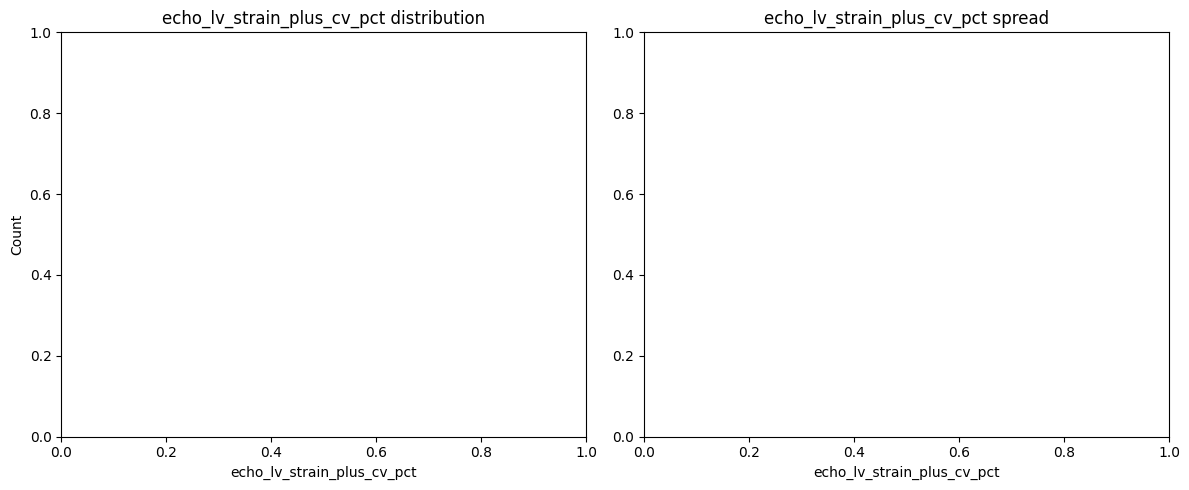


echo_lv_strain_rate_cv_pct
n: 0
mean: nan
median: nan
std: nan
IQR: nan
skewness: nan
kurtosis: nan

Quantiles:


C:\Users\Ars\AppData\Local\Temp\ipykernel_29548\2845845498.py:23: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print("skewness:", round(stats.skew(d[var]), 2))
C:\Users\Ars\AppData\Local\Temp\ipykernel_29548\2845845498.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print("kurtosis:", round(stats.kurtosis(d[var]), 2))


0.10   NaN
0.25   NaN
0.50   NaN
0.75   NaN
0.90   NaN
0.95   NaN
Name: echo_lv_strain_rate_cv_pct, dtype: float64

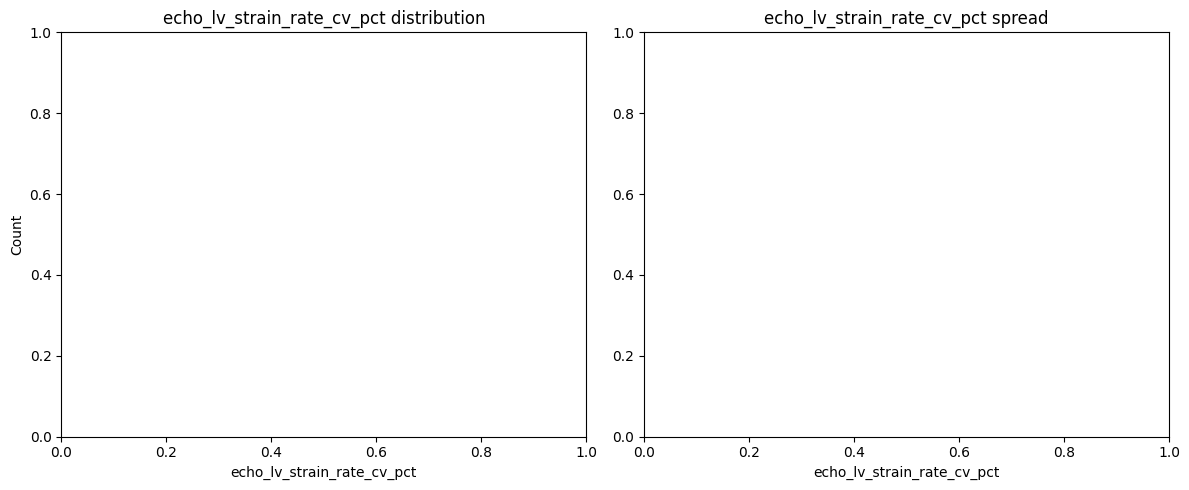

In [11]:
# ==========================================
# STRAIN DISTRIBUTION ANALYSIS
# ==========================================

strain_vars = [
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
]

for var in strain_vars:

    d = df[[var]].dropna().copy()

    print("\n" + "=" * 70)
    print(var)
    print("=" * 70)

    print("n:", len(d))
    print("mean:", round(d[var].mean(), 2))
    print("median:", round(d[var].median(), 2))
    print("std:", round(d[var].std(), 2))
    print("IQR:", round(d[var].quantile(0.75) - d[var].quantile(0.25), 2))
    print("skewness:", round(stats.skew(d[var]), 2))
    print("kurtosis:", round(stats.kurtosis(d[var]), 2))

    print("\nQuantiles:")
    display(
        d[var].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5),
        facecolor="white",
    )

    # -----------------------------------
    # Histogram
    # -----------------------------------

    sns.histplot(
        d[var],
        bins=10,
        kde=True,
        color="lightgray",
        edgecolor="black",
        ax=axes[0],
    )

    sns.rugplot(
        d[var],
        color="black",
        height=0.05,
        ax=axes[0],
    )

    axes[0].set_title(f"{var} distribution")
    axes[0].set_xlabel(var)
    axes[0].set_ylabel("Count")

    # -----------------------------------
    # Boxplot + stripplot
    # -----------------------------------

    sns.boxplot(
        x=d[var],
        color="white",
        linewidth=1.5,
        whis=1.5,
        ax=axes[1],
    )

    sns.stripplot(
        x=d[var],
        color="black",
        alpha=0.7,
        size=6,
        jitter=0.08,
        ax=axes[1],
    )

    axes[1].set_title(f"{var} spread")
    axes[1].set_xlabel(var)

    plt.tight_layout()
    plt.show()

In [12]:
strain_cols = [
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
]

for col in strain_cols:
    print("\n", col)
    print(df[col].notna().sum())


 echo_lv_strain_plus_cv_pct
0

 echo_lv_strain_rate_cv_pct
0


## Important clarification regarding strain variables

During exploratory analysis it was identified that:

- `echo_lv_strain_plus_cv_pct`
- `echo_lv_strain_rate_cv_pct`

do not represent coefficients of variation.

The variables contain negative deformation values typical for myocardial strain and strain rate measurements. Therefore:

- DICOR variables represent mechanical dispersion / variability,
- Strain variables represent deformation magnitude rather than variability.

Accordingly, DICOR and Speckle-Tracking datasets describe different physiological domains and should not be interpreted as identical measures of heterogeneity.